<a href="https://colab.research.google.com/github/dachishonia/fer-challenge/blob/main/notebooks/fer_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wandb kaggle tqdm pyyaml scikit-learn seaborn -q

In [ ]:
import gdown

In [ ]:
DATA_DIR = '/content/fer2013/fer2013'
ZIP_PATH = f'{DATA_DIR}/fer2013.tar.gz' # Changed to .tar.gz
CSV_PATH = f'{DATA_DIR}/fer2013.csv'
GOOGLE_DRIVE_FOLDER_ID = '1im8rf3cGWWS_c8J6-Xiay3iYY55efzPQ' # Keeping for reference

if not os.path.exists(CSV_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    if os.path.exists(ZIP_PATH):
        print(f"Found {ZIP_PATH}. Extracting...")
        !tar -xzf {ZIP_PATH} -C {DATA_DIR} # Changed from unzip to tar -xzf
        print('Data extraction complete.')
    else:
        print(f"Data not found. Please manually download 'fer2013.tar.gz' from your Google Drive link and upload it to the Colab environment at:")
        print(f"  {ZIP_PATH}")
        print("Alternatively, if the Google Drive folder '" + GOOGLE_DRIVE_FOLDER_ID + "' is publicly accessible, you can try running `!gdown --id <file_id_of_fer2013.tar.gz> --output {ZIP_PATH}` if you have the direct file ID.")
        print("After uploading or successful gdown, rerun this cell to extract the data.")
else:
    print('Data already downloaded and extracted.')

# After download and unzip, verify if CSV_PATH exists
if not os.path.exists(CSV_PATH):
    print(f"Warning: {CSV_PATH} not found. Please follow the instructions above to get the data.")
else:
    print(f"Data ready at {CSV_PATH}")

Found /content/fer2013/fer2013/fer2013.tar.gz. Extracting...

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now
Data extraction complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

REPO = '/content/fer-challenge'

if not os.path.exists(REPO):
    !git clone https://github.com/dachishonia/fer-challenge.git $REPO
else:
    !git -C $REPO pull

sys.path.insert(0, REPO)
sys.path.insert(0, f'{REPO}/src')
print('Repo ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Repo ready.


In [ ]:
!git -C /content/fer-challenge pull

Already up to date.


In [ ]:
import importlib
import dataset, models, train, utils

importlib.reload(dataset)
importlib.reload(models)
importlib.reload(train)
importlib.reload(utils)

from dataset import get_dataloaders, get_class_weights, EMOTION_LABELS
from models  import get_model, count_parameters
from train   import train_model, overfit_single_batch
from utils   import run_sanity_checks

print('Modules reloaded.')

Modules reloaded.


In [ ]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": "davitishonia",
    "key": "KGAT_5ea9b4e1d64d98ae1e778bec0be65bbe"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("kaggle.json created successfully!")

kaggle.json created successfully!


In [ ]:
DATA_DIR = '/content/fer2013/fer2013'
CSV_PATH = f'{DATA_DIR}/fer2013.csv'

if not os.path.exists(CSV_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    !kaggle competitions download \
        -c challenges-in-representation-learning-facial-expression-recognition-challenge \
        -p {DATA_DIR}
    !unzip -q {DATA_DIR}/*.zip -d {DATA_DIR}
    print('Done.')
else:
    print('Already downloaded.')

Already downloaded.


In [ ]:
import pandas as pd

# CSV_PATH is expected to be defined in the preceding data download cell (81339fc6).
# This cell will attempt to read the CSV.
df = pd.read_csv(CSV_PATH)
print(f'Rows   : {len(df)}')
print(f'Splits : {df["Usage"].value_counts().to_dict()}')

Rows   : 15618
Splits : {'Training': 15617}


In [ ]:
import wandb
wandb.login()  # It will ask for your API key — paste it here

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dshon23 (dshon23-free-university-of-tbilisi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

from dataset import get_dataloaders, get_class_weights, EMOTION_LABELS
from models  import get_model, count_parameters
from train   import train_model, overfit_single_batch
from utils   import run_sanity_checks

Device : cpu


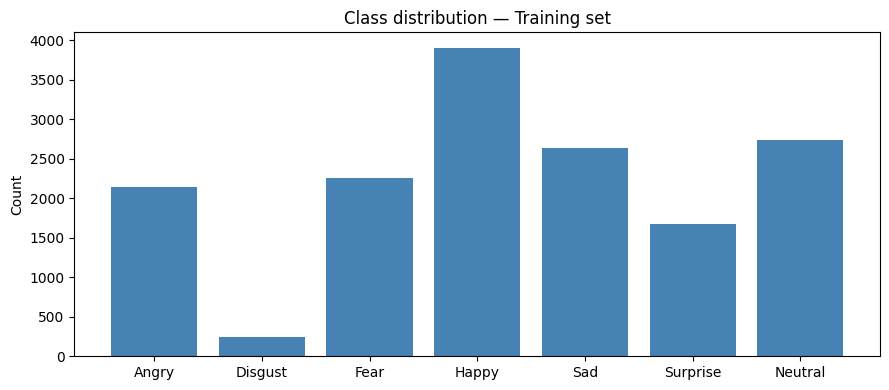

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# df and EMOTION_LABELS are expected to be defined in previous cells (JaJCSY-FsJzZ and lZt8k4JmoGTY).
# Removed redundant CSV_PATH and df loading, and duplicate print statements.

train_df = df[df['Usage'] == 'Training']
counts = train_df['emotion'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(EMOTION_LABELS, counts.values, color='steelblue')
ax.set_title('Class distribution — Training set')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

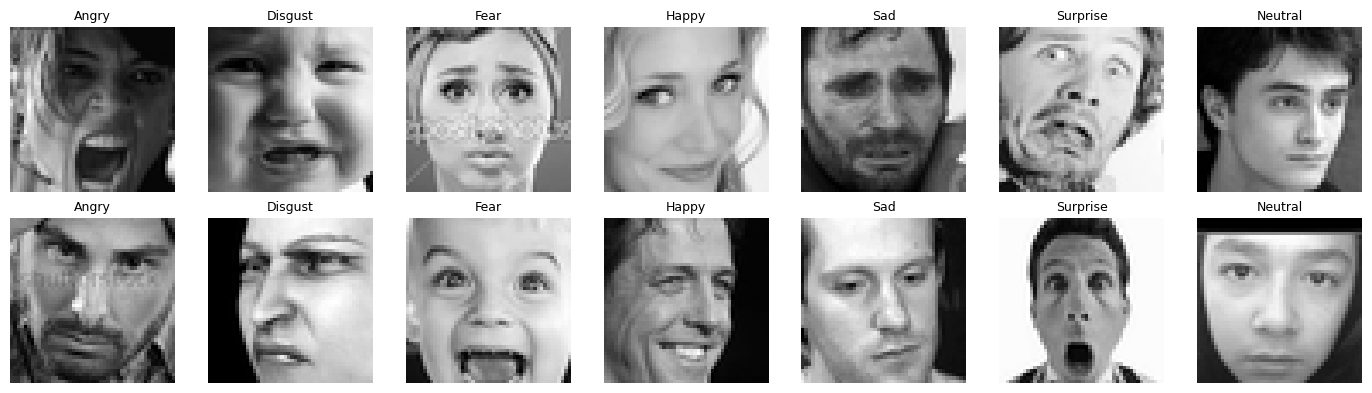

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for emotion_id in range(7):
    rows = train_df[train_df['emotion'] == emotion_id].sample(2, random_state=42)
    for row_idx, (_, row) in enumerate(rows.iterrows()):
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        axes[row_idx, emotion_id].imshow(pixels, cmap='gray')
        axes[row_idx, emotion_id].set_title(EMOTION_LABELS[emotion_id], fontsize=9)
        axes[row_idx, emotion_id].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class_weights = get_class_weights(CSV_PATH)
for label, w in zip(EMOTION_LABELS, class_weights):
    print(f'  {label:10s}: {w:.3f}')

  Angry     : 0.496
  Disgust   : 4.331
  Fear      : 0.472
  Happy     : 0.273
  Sad       : 0.403
  Surprise  : 0.636
  Neutral   : 0.388


##   **TinyCNN**  3-ჯერ

In [ ]:
CSV_PATH = '/content/fer2013/fer2013/fer2013.csv'
class_weights = get_class_weights(CSV_PATH)
train_loader, val_loader, _ = get_dataloaders(CSV_PATH, batch_size=64, augment=False)

# Sanity check
model = get_model('tiny_cnn').to(device)
print(f'Params: {count_parameters(model)[0]:,}')
run_sanity_checks(model, train_loader, device)
overfit_single_batch(get_model('tiny_cnn').to(device), train_loader, device, steps=50)

# Run 1
cfg = {'run_name':'tiny_cnn_v1_adam_lr1e3','architecture':'tiny_cnn','epochs':40,'lr':1e-3,'optimizer':'adam','scheduler':'plateau','batch_size':64,'dropout':0.0,'augment':False,'weight_decay':0.0,'for_transfer':False,'early_stop_patience':15}
model, acc = train_model(get_model('tiny_cnn').to(device), cfg, train_loader, val_loader, device, class_weights)
print(f'Run1 best val acc: {acc:.3f}')

# Run 2
cfg2 = {**cfg, 'run_name':'tiny_cnn_v2_adam_lr1e2', 'lr':1e-2}
model, acc = train_model(get_model('tiny_cnn').to(device), cfg2, train_loader, val_loader, device, class_weights)
print(f'Run2 best val acc: {acc:.3f}')

# Run 3
cfg3 = {**cfg, 'run_name':'tiny_cnn_v3_sgd', 'lr':1e-2, 'optimizer':'sgd', 'scheduler':'step', 'weight_decay':1e-4}
model, acc = train_model(get_model('tiny_cnn').to(device), cfg3, train_loader, val_loader, device, class_weights)
print(f'Run3 best val acc: {acc:.3f}')

Train: 28709 | Val: 3589 | Test: 3589
Params: 17,383

─── Sanity Checks ───────────────────────────────────────────
  [Forward Check]
    Output shape : (64, 7)
    Initial loss : 1.9519  (expected ~1.9459 for random model)
    NaN detected : False
  [Backward Check]
    Layers checked  : 6
    Dead layers     : None
    Grad norm min   : 0.016116
    Grad norm max   : 1.227586
─────────────────────────────────────────────────────────────

Single-batch overfit test:
  step  10 | loss=1.8000 | acc=0.234
  step  20 | loss=1.3292 | acc=0.500
  step  30 | loss=0.6922 | acc=0.828
  step  40 | loss=0.1789 | acc=0.969
  step  50 | loss=0.0168 | acc=1.000


Epoch   1/40 | train loss=1.7945 acc=0.296 | val loss=1.6642 acc=0.371 | lr=0.001000


Epoch   2/40 | train loss=1.6184 acc=0.388 | val loss=1.5818 acc=0.417 | lr=0.001000


Epoch   3/40 | train loss=1.5304 acc=0.422 | val loss=1.5550 acc=0.441 | lr=0.001000


Epoch   4/40 | train loss=1.4627 acc=0.446 | val loss=1.5118 acc=0.425 | lr=0.001000


...

Epoch  28/40 | train loss=1.0242 acc=0.590 | val loss=1.5560 acc=0.474 | lr=0.002500


Epoch  29/40 | train loss=1.0244 acc=0.592 | val loss=1.5747 acc=0.468 | lr=0.002500


Epoch  30/40 | train loss=1.0174 acc=0.589 | val loss=1.5755 acc=0.468 | lr=0.002500
Early stopping at epoch 30.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,██████████▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train/loss,█▇▆▅▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▇▆▇▇▇▇▇▇▇█▇▇████████████████
val/loss,█▅▅▃▁▁▁▁▂▁▂▁▁▁▂▂▂▂▃▂▃▃▄▃▃▄▄▄▄▄
best_val_acc,0.48036
epoch,30
lr,0.0025
train/acc,0.58922
train/loss,1.01744


Run3 best val acc: 0.480


##   **SmallCNN**  2-ჯერ

In [ ]:
# Run 1 - no regularization (will overfit)
train_loader, val_loader, _ = get_dataloaders(CSV_PATH, batch_size=64, augment=False)
cfg = {'run_name':'small_cnn_v1_no_reg','architecture':'small_cnn','epochs':60,'lr':1e-3,'optimizer':'adam','scheduler':'plateau','batch_size':64,'dropout':0.0,'augment':False,'weight_decay':0.0,'for_transfer':False,'early_stop_patience':20}
model = get_model('small_cnn', dropout=0.0).to(device)
print(f'Params: {count_parameters(model)[0]:,}')
run_sanity_checks(model, train_loader, device)
model, acc = train_model(get_model('small_cnn', dropout=0.0).to(device), cfg, train_loader, val_loader, device, class_weights)
print(f'Run1 best val acc: {acc:.3f}')

# Run 2 - add dropout
train_loader, val_loader, _ = get_dataloaders(CSV_PATH, batch_size=64, augment=True)
cfg2 = {**cfg, 'run_name':'small_cnn_v2_dropout', 'dropout':0.3, 'augment':True, 'weight_decay':1e-4}
model, acc = train_model(get_model('small_cnn', dropout=0.3).to(device), cfg2, train_loader, val_loader, device, class_weights)
print(f'Run2 best val acc: {acc:.3f}')

Train: 28709 | Val: 3589 | Test: 3589
Params: 834,183

─── Sanity Checks ───────────────────────────────────────────
  [Forward Check]
    Output shape : (64, 7)
    Initial loss : 1.9571  (expected ~1.9459 for random model)
    NaN detected : False
  [Backward Check]
    Layers checked  : 12
    Dead layers     : None
    Grad norm min   : 0.001433
    Grad norm max   : 0.178959
─────────────────────────────────────────────────────────────



Epoch   1/60 | train loss=1.8372 acc=0.254 | val loss=1.6370 acc=0.392 | lr=0.001000


Epoch   2/60 | train loss=1.5218 acc=0.424 | val loss=1.4179 acc=0.464 | lr=0.001000


Epoch   3/60 | train loss=1.3483 acc=0.488 | val loss=1.3867 acc=0.503 | lr=0.001000


Epoch   4/60 | train loss=1.2208 acc=0.531 | val loss=1.3831 acc=0.495 | lr=0.001000


...

Epoch  58/60 | train loss=1.1274 acc=0.569 | val loss=1.1836 acc=0.569 | lr=0.000125


Epoch  59/60 | train loss=1.1281 acc=0.574 | val loss=1.1670 acc=0.568 | lr=0.000125


Epoch  60/60 | train loss=1.1195 acc=0.576 | val loss=1.1759 acc=0.568 | lr=0.000125


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇████
lr,███████████████████████████▄▄▄▄▂▂▂▂▂▁▁▁▁
train/acc,▁▂▃▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▇▆▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
val/loss,█▆▅▅▄▃▃▃▂▂▂▃▂▂▂▃▂▂▂▁▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.57063
epoch,60
lr,0.00013
train/acc,0.5763
train/loss,1.11954


Run2 best val acc: 0.571


##   **MediumCNN**  3-ჯერ

In [ ]:
for dropout, sched, bs, name in [
    (0.3, 'plateau', 64, 'medium_cnn_v1_dropout03'),
    (0.5, 'plateau', 64, 'medium_cnn_v2_dropout05'),
    (0.4, 'cosine',  32, 'medium_cnn_v3_cosine'),
]:
    tl, vl, _ = get_dataloaders(CSV_PATH, batch_size=bs, augment=True)
    cfg = {'run_name':name,'architecture':'medium_cnn','epochs':60,'lr':1e-3,'optimizer':'adam','scheduler':sched,'batch_size':bs,'dropout':dropout,'augment':True,'weight_decay':1e-4,'for_transfer':False,'early_stop_patience':15}
    m = get_model('medium_cnn', dropout=dropout).to(device)
    print(f'\n{name} — params: {count_parameters(m)[0]:,}')
    m, acc = train_model(m, cfg, tl, vl, device, class_weights)
    print(f'Best val acc: {acc:.3f}')

Train: 28709 | Val: 3589 | Test: 3589

medium_cnn_v1_dropout03 — params: 1,635,527


Epoch   1/60 | train loss=1.9484 acc=0.181 | val loss=1.9146 acc=0.157 | lr=0.001000


Epoch   2/60 | train loss=1.9360 acc=0.192 | val loss=1.8984 acc=0.234 | lr=0.001000


Epoch   3/60 | train loss=1.8752 acc=0.242 | val loss=1.7612 acc=0.337 | lr=0.001000


Epoch   4/60 | train loss=1.7992 acc=0.308 | val loss=1.6495 acc=0.395 | lr=0.001000


...

Epoch  58/60 | train loss=1.1867 acc=0.568 | val loss=1.0790 acc=0.602 | lr=0.000006


Epoch  59/60 | train loss=1.1684 acc=0.575 | val loss=1.0808 acc=0.602 | lr=0.000003


Epoch  60/60 | train loss=1.1701 acc=0.575 | val loss=1.0816 acc=0.600 | lr=0.000001


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
lr,████████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
train/acc,▁▁▁▂▃▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train/loss,███▇▇▅▅▅▄▄▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▃▂▂▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
val/loss,██▇▅▄▄▄▃▃▃▃▂▂▃▂▂▂▂▂▂▂▁▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.6024
epoch,60
lr,0.0
train/acc,0.57526
train/loss,1.17011


Best val acc: 0.602


##   **ResNetStyleCNN**  2-ჯერ

In [ ]:
import torch
from dataset import get_dataloaders
from models import get_model, count_parameters
from train import train_model

for sched, name in [('plateau','resnet_style_v1_plateau'), ('cosine','resnet_style_v2_cosine')]:
    tl, vl, _ = get_dataloaders(CSV_PATH, batch_size=64, augment=True)
    cfg = {'run_name':name,'architecture':'resnet_style','epochs':25,'lr':1e-3,'optimizer':'adam','scheduler':sched,'batch_size':64,'dropout':0.4,'augment':True,'weight_decay':1e-4,'for_transfer':False,'early_stop_patience':8}
    m = get_model('resnet_style', dropout=0.4).to(device)
    m, acc = train_model(m, cfg, tl, vl, device, class_weights)
    print(f'{name}: {acc:.3f}')

##   **TransferLearning**  2-ჯერ

In [ ]:
tl5, vl5, _ = get_dataloaders(CSV_PATH, batch_size=32, augment=True, for_transfer=True)

# Run 1 - mostly frozen
cfg = {'run_name':'transfer_mobilenet_v1_frozen','architecture':'transfer_learning','epochs':15,'lr':3e-4,'optimizer':'adam','scheduler':'plateau','batch_size':32,'dropout':0.5,'augment':True,'weight_decay':1e-4,'for_transfer':True,'early_stop_patience':5}
m = get_model('transfer_learning', dropout=0.5, freeze_until=-3).to(device)
m, acc = train_model(m, cfg, tl5, vl5, device, class_weights)
print(f'Transfer frozen: {acc:.3f}')

# Run 2 - fine-tune more layers
cfg2 = {**cfg, 'run_name':'transfer_mobilenet_v2_finetune','lr':1e-4,'scheduler':'cosine','dropout':0.3,'weight_decay':5e-5}
m2 = get_model('transfer_learning', dropout=0.3, freeze_until=-6).to(device)
m2, acc2 = train_model(m2, cfg2, tl5, vl5, device, class_weights)
print(f'Transfer finetune: {acc2:.3f}')

Train: 15617 | Val: 0 | Test: 0


train:   0%|          | 0/489 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
train:  57%|█████▋    | 279/489 [13:56<10:21,  2.96s/it]

In [ ]:
print('All done! View results at: https://wandb.ai/dshon23-free-university-of-tbilisi/fer-challenge')